### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

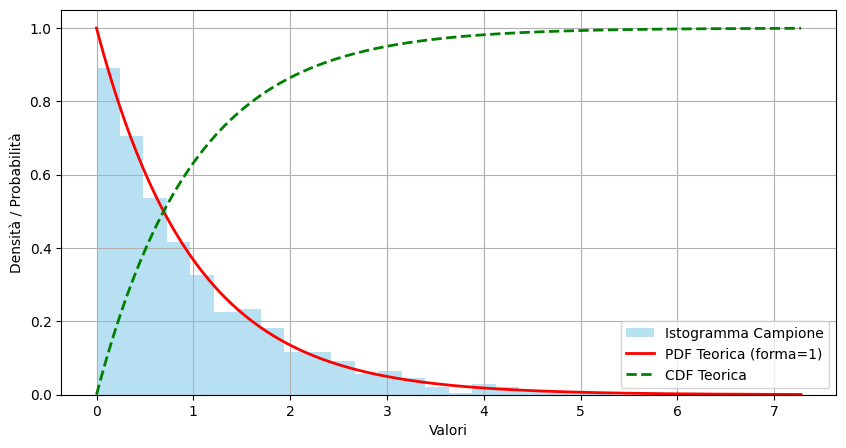

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
#a
gamma_dist =sp.stats.gamma(1)


#b
campione= gamma_dist.rvs(size=1000)

#c
plt.figure(figsize=(10, 5))
plt.hist(campione, bins=30, density=True, alpha=0.6, color='skyblue', label='Istogramma Campione')

#d
x_asse =np.linspace(0, np.max(campione), 200)
plt.plot(x_asse, gamma_dist.pdf(x_asse), 'r-', lw=2, label='PDF Teorica (forma=1)')




# e
plt.plot(x_asse,gamma_dist.cdf(x_asse), 'g--', lw=2, label='CDF Teorica')


plt.xlabel("Valori")
plt.ylabel("Densità / Probabilità")
plt.legend()
plt.grid(True)
plt.show()

# f
parametri_stimati= sp.stats.gamma.fit(campione)
forma_stimata= parametri_stimati[0]






#g
varianza_teorica =gamma_dist.var()


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

massime MAE: 1.05, RMSE: 1.19
minime  MAE: 3.19, RMSE: 3.83


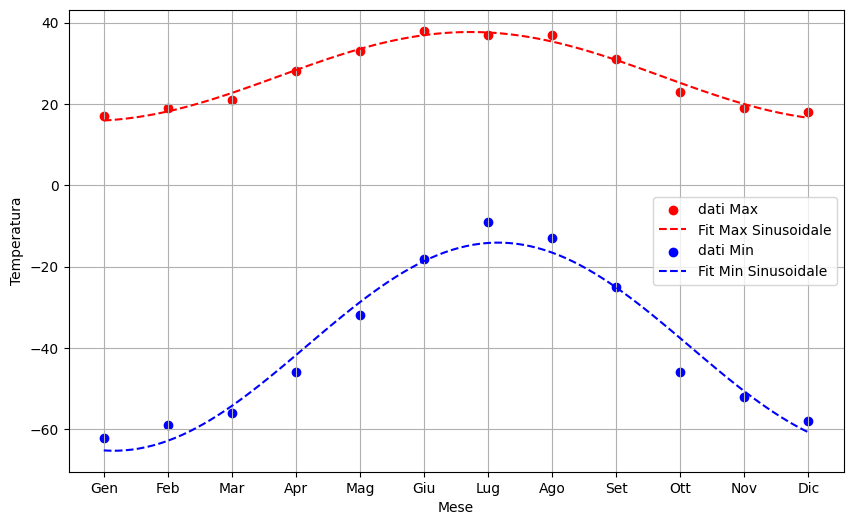

In [3]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt


mesi = np.arange(12)
def calcola_mae(reali, previsti):
    return np.mean(np.abs(reali - previsti))
def calcola_rmse(reali, previsti):
    return np.sqrt(np.mean((reali - previsti) ** 2))
def modello_temperatura(t, offset, ampiezza, fase):
    return offset + ampiezza * np.cos(2 * np.pi * t / 12 + fase)





popt_max, _ = sp.optimize.curve_fit(modello_temperatura, mesi, temp_max, p0=[20, 10, 0])
temp_max_pred = modello_temperatura(mesi, *popt_max)
popt_min, _ = sp.optimize.curve_fit(modello_temperatura, mesi, temp_min, p0=[10, 10, 0])
temp_min_pred = modello_temperatura(mesi, *popt_min)



mae_max = calcola_mae(temp_max, temp_max_pred)
rmse_max = calcola_rmse(temp_max, temp_max_pred)
mae_min = calcola_mae(temp_min, temp_min_pred)
rmse_min = calcola_rmse(temp_min, temp_min_pred)


print(f"massime MAE: {mae_max:.2f}, RMSE: {rmse_max:.2f}")
print(f"minime  MAE: {mae_min:.2f}, RMSE: {rmse_min:.2f}")



mesi_continui = np.linspace(0, 11, 100)

plt.figure(figsize=(10, 6))
plt.scatter(mesi, temp_max, color='red', label='dati Max')
plt.plot(mesi_continui, modello_temperatura(mesi_continui, *popt_max), 'r--', label='Fit Max Sinusoidale')
plt.scatter(mesi, temp_min, color='blue', label='dati Min')
plt.plot(mesi_continui, modello_temperatura(mesi_continui, *popt_min), 'b--', label='Fit Min Sinusoidale')





plt.xlabel("Mese")
plt.ylabel("Temperatura")
plt.xticks(mesi, ['Gen','Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set','Ott', 'Nov','Dic'])
plt.legend()
plt.grid(True)  
plt.show()


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

mpg = -0.0412 * disp + 29.5999


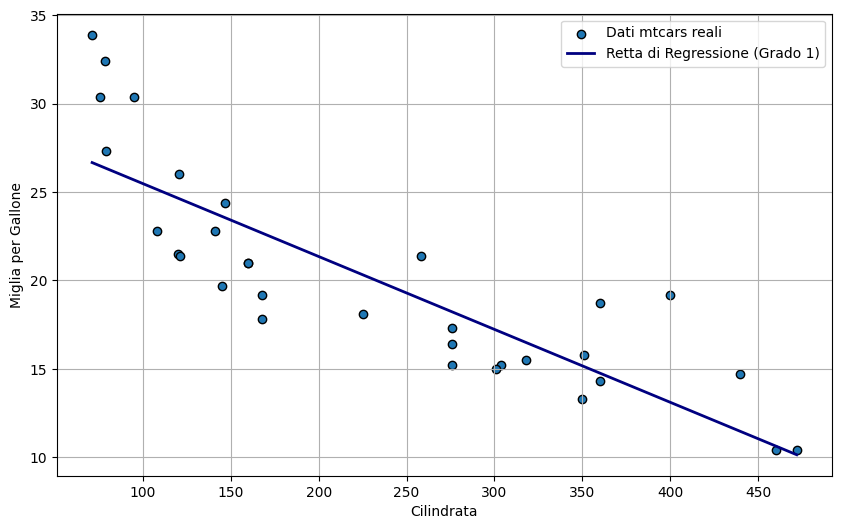

In [ ]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')




X_disp = df['disp'].values
Y_mpg = df['mpg'].values


coefficienti = np.polyfit(X_disp, Y_mpg, deg=1)
m, q = coefficienti[0], coefficienti[1]



modello_lineare = np.poly1d(coefficienti)
Y_mpg_pred = modello_lineare(X_disp)



print(f"mpg = {m:.4f} * disp + {q:.4f}")




plt.figure(figsize=(10, 6))
plt.scatter(X_disp, Y_mpg, edgecolor='k', label='Dati mtcars reali')
x_linea = np.linspace(np.min(X_disp), np.max(X_disp), 100)
plt.plot(x_linea, modello_lineare(x_linea), color='navy', lw=2, label='Retta di Regressione (Grado 1)')
plt.xlabel("Cilindrata")
plt.ylabel("Miglia per Gallone")
plt.legend()
plt.grid(True)
plt.show()